# 微调


## 简介
迁移学习的方法之一，在预训练模型的基础上，使用较小的数据集进行进一步训练，使模型更好地适应新任务。

- 预训练模型:
  - 在大规模数据集上训练得到
  - 强大的特征提取能力
  - 提取后原始像素变成容易线性分割的特征
- 微调:
  - 用小数据集训练
  - 适应新任务
  - 对提取的特征进行其他变换

## 微调方式
### 权重初始化
一般不改“特征提取器”，只改“分类头”

![tunning](./images/tunning.svg)

### 训练
- 训练不应改太多，以免过拟合
  - 使用更强的正则化
  - 使用更小的学习率
  - 使用更少的数据迭代
- 最好原数据集远复杂于目标数据

### 重用分类器权重
- 原数据集可能也有目标数据中的部分标号

- 可以用预训练模型分类器中对应标号的向量做初始化

### 固定层
神经网络通常学习有层次的特征表示
- 底层特征更通用
- 高层特征和数据集和任务更相关

因此可以固定底部一些层的参数，只训练顶部的层。


## 实现


In [1]:
%matplotlib inline
import os
import torch
import torchvision
from torch import nn
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


热狗数据集


In [2]:
util.data.DATA_HUB['hotdog'] = (util.data.DATA_URL + 'hotdog.zip',
                         'fba480ffa8aa7e0febbb511d181409f899b9baa5')
data_dir = util.data.download_extract('hotdog')

train_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'))
test_imgs = torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'))

有的是热狗有的不是，图片有多种高宽比


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

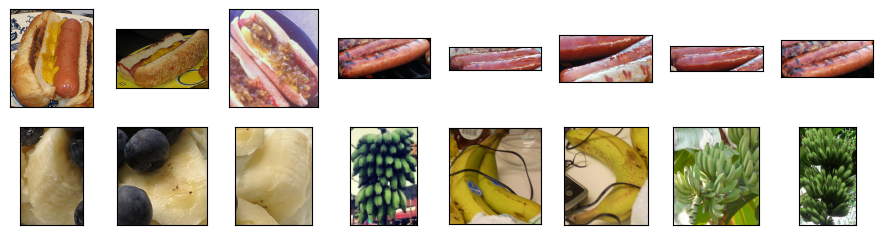

In [3]:
hotdogs = [train_imgs[i][0] for i in range(8)]
not_hotdogs = [train_imgs[-i - 1][0] for i in range(8)]
util.show_images(hotdogs + not_hotdogs, 2, 8, scale=1.4)

数据增广


In [4]:
# RGB 通道上的归一化，因为 ImageNet 上的预训练模型都是在归一化后的图像上训练的
normalize = torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225])

train_aug = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),  # 随机裁剪为 224x224
    torchvision.transforms.RandomHorizontalFlip(),  # 随机水平翻转
    torchvision.transforms.ToTensor(),               # 转为张量
    normalize])                                      # 归一化

test_aug = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),                      # 调整图像大小为 256x256
    torchvision.transforms.CenterCrop(224),                 # 中心裁剪为 224x224
    torchvision.transforms.ToTensor(),                      # 转为张量
    normalize])                                              # 归一化

初始化模型


In [5]:
# 加载预训练模型
pretrained_net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
# 看全连接层
pretrained_net.fc

Linear(in_features=512, out_features=1000, bias=True)

重新初始化全连接层


In [6]:
finetune_net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
# 重定义全连接层，输出两类
finetune_net.fc = nn.Linear(finetune_net.fc.in_features, 2)
# Xavier 初始化
nn.init.xavier_normal_(finetune_net.fc.weight)
finetune_net.fc

Linear(in_features=512, out_features=2, bias=True)

搞一个新模型做对照


In [7]:
scratch_net = torchvision.models.resnet18(weights=None)
scratch_net.fc = nn.Linear(scratch_net.fc.in_features, 2)
nn.init.xavier_normal_(scratch_net.fc.weight)

Parameter containing:
tensor([[-0.0073, -0.0225, -0.0234,  ...,  0.0684,  0.0024,  0.0182],
        [-0.0244,  0.0397, -0.0030,  ..., -0.0293, -0.0159, -0.0281]],
       requires_grad=True)

微调模型


In [8]:
def train_fine_tuning(net, lr=5e-5, batch_size=128,
                      num_epochs=5, weight_decay=1e-3,
                      devices=util.try_all_gpus(), param_group=True):
    train_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_aug),
        batch_size=batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=test_aug),
        batch_size=batch_size, shuffle=False)
    loss = nn.CrossEntropyLoss()
    if param_group:
        params_1x = [param for name, param in net.named_parameters() if name not in ['fc.weight', 'fc.bias']]
        optimizer = torch.optim.Adam([
            {'params': params_1x, 'lr': lr},  # 特征提取器的参数使用较小的学习率
            {'params': net.fc.parameters()}], lr=lr * 10, weight_decay=weight_decay)  # 全连接层的参数使用较大的学习率
    else: # 训练整个模型
        optimizer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)
    util.train.train_ch13(net, train_iter, test_iter, loss, optimizer, num_epochs, devices)

训练微调模型

loss 0.001, train acc 0.963, test acc 0.953
1902.2 examples/sec on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2)]


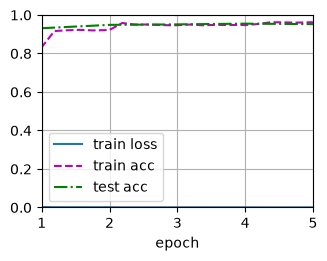

In [9]:
train_fine_tuning(finetune_net, lr=5e-5)

训练从头开始的模型


loss 0.003, train acc 0.858, test acc 0.848
2663.2 examples/sec on [device(type='cuda', index=0), device(type='cuda', index=1), device(type='cuda', index=2)]


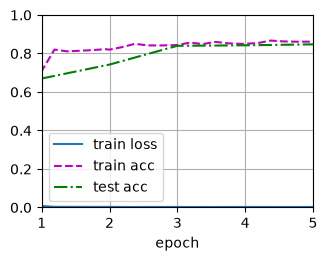

In [10]:
train_fine_tuning(scratch_net, lr=5e-4, param_group=False)